# Model Explainability using SHAP

Modern credit risk models should not only predict accurately but also provide transparent explanations for their decisions.

This notebook explains the predictions of the final XGBoost model using SHAP (SHapley Additive exPlanations).

The objectives are:

- Identify the most influential risk factors globally
- Explain individual customer predictions
- Improve transparency for credit decision-making
- Support ethical and interpretable AI

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [3]:
!pip install shap

In [4]:
import shap

shap.initjs()

In [5]:
path = "/content/drive/MyDrive/Credit_Risk_Project/data/validation_predictions.csv"

val_results = pd.read_csv(path)

val_results.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT6,pay_delay_trend,pay_delay_volatility,pay_trend,recency_weighted_stress,bill_payment_ratio,avg_utilization,true_default,log_pred_prob,rf_pred_prob
0,50000,1,2,1,45,1,2,0,0,0,...,706,0.314286,0.836660,1,10.0,42.696168,0.791160,1,0.469079,0.384292
1,80000,2,2,1,30,1,2,0,0,0,...,3100,0.314286,0.836660,1,10.0,31.575774,0.992729,0,0.401860,0.453451
2,160000,1,3,1,42,1,-1,-1,-2,-1,...,0,0.171429,1.032796,1,-7.0,0.640459,0.001629,0,0.347572,0.214714
3,20000,1,2,1,31,1,4,3,2,0,...,1000,0.514286,1.632993,1,27.5,40.334331,1.010375,0,0.662154,0.508630
4,130000,2,2,2,26,0,0,0,2,2,...,5050,-0.514286,1.095445,-2,9.0,23.387867,1.009306,0,0.292173,0.351828


In [6]:
feature_path = "/content/drive/MyDrive/Credit_Risk_Project/data/behavioral_features.csv"

df = pd.read_csv(feature_path)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,default,pay_delay_trend,pay_delay_volatility,pay_trend,recency_weighted_stress,bill_payment_ratio,avg_utilization
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,1,0.914286,1.861899,4,4.5,11.084892,0.064200
1,2,120000,2,2,2,26,-1,2,0,0,...,1000,0,2000,1,-0.257143,1.224745,-3,4.0,3.411306,0.023718
2,3,90000,2,2,2,34,0,0,0,0,...,1000,1000,5000,0,0.000000,0.000000,0,0.0,9.221063,0.188246
3,4,50000,2,2,1,37,0,0,0,0,...,1100,1069,1000,0,0.000000,0.000000,0,0.0,27.559447,0.771113
4,5,50000,1,2,1,57,-1,0,-1,0,...,9000,689,679,0,-0.171429,0.516398,-1,-6.5,1.851477,0.364463


In [7]:
target = "default"

features = [
    col for col in df.columns
    if col not in ["ID", target]
]

X = df[features]
y = df[target]

In [8]:
model = joblib.load(
    "/content/drive/MyDrive/Credit_Risk_Project/models/xgb_model.pkl"
)

model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

## Global Feature Importance

SHAP computes the contribution of every feature toward model predictions.

Higher absolute SHAP values indicate stronger influence on predicted default risk.

In [9]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)

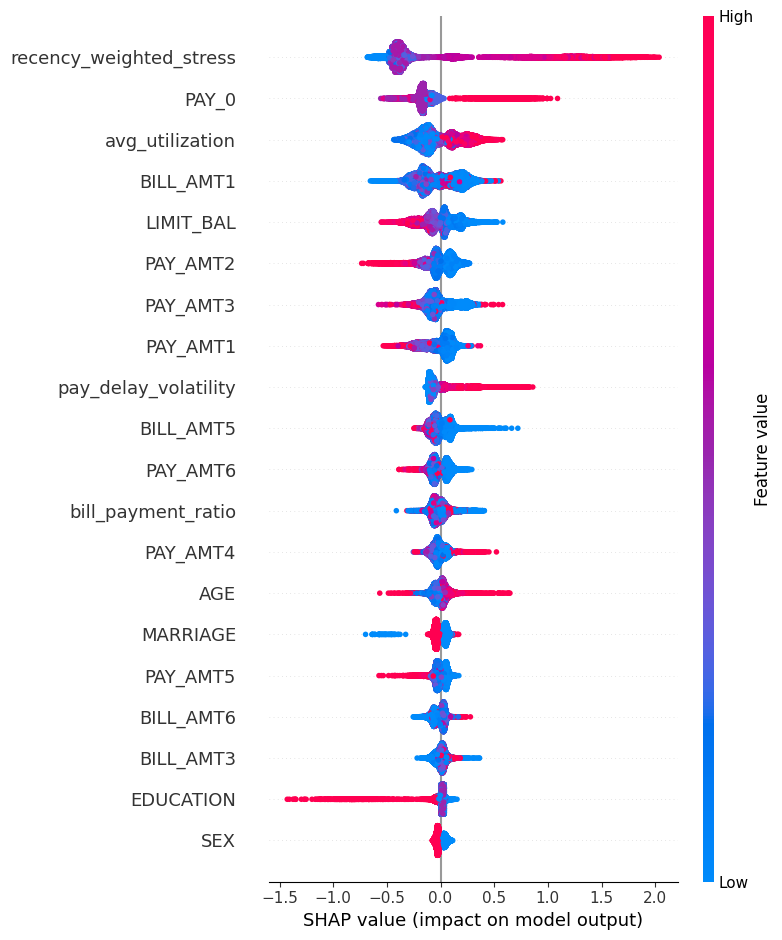

In [10]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X,
    show=False
)

plt.tight_layout()
plt.show()

Interpretation

Features appearing near the top of the plot contribute most strongly to predicted credit risk.

Red points indicate larger feature values.

Blue points indicate smaller feature values.

Horizontal spread reflects the magnitude of impact on prediction.

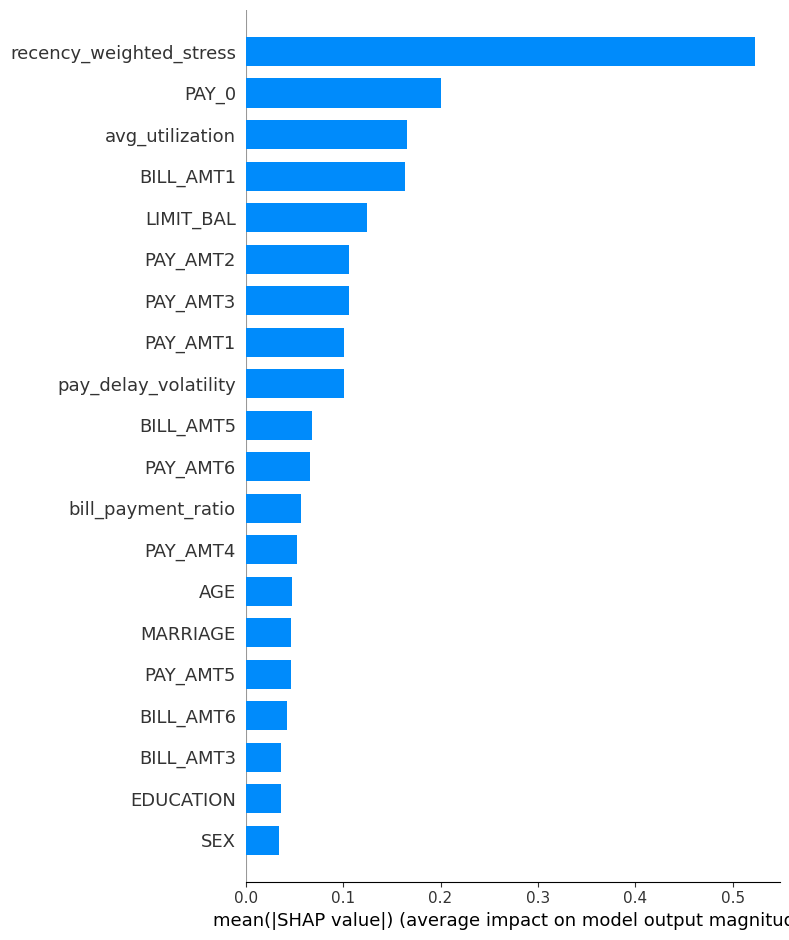

In [11]:
plt.figure(figsize=(8,6))

shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.show()

The bar chart summarizes the average absolute contribution of each feature across all customers.

These represent the primary drivers of financial stress identified by the model.

## Explaining an Individual Customer

SHAP can explain why a specific customer receives a high predicted probability of default.

This improves transparency and helps credit analysts understand model decisions.

In [12]:
predictions = model.predict_proba(X)[:,1]

highest_risk = np.argmax(predictions)

highest_risk

np.int64(26801)

In [13]:
print("Predicted Default Probability:")

print(round(predictions[highest_risk],3))

Predicted Default Probability:
0.952


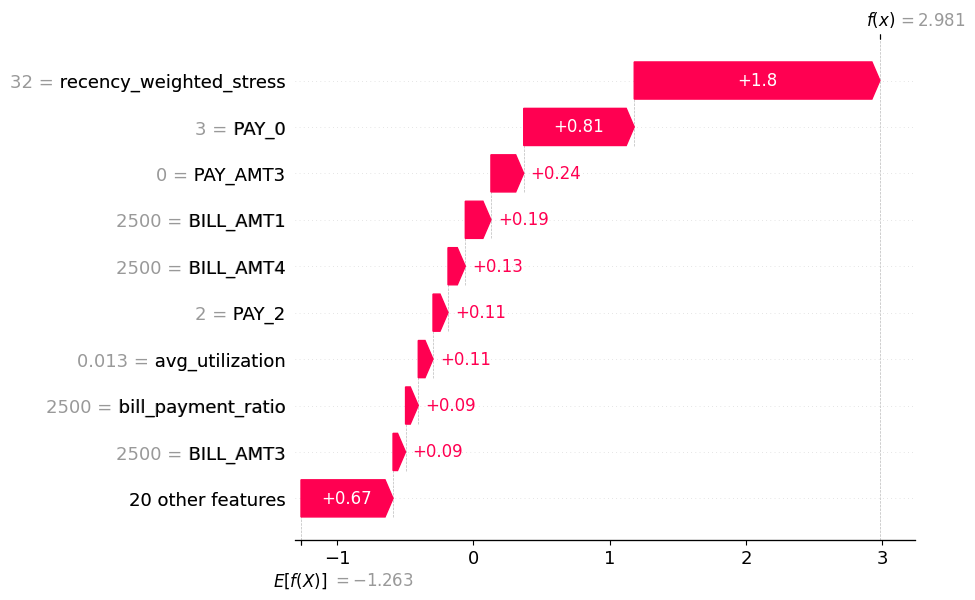

In [14]:
explanation = explainer(X.iloc[[highest_risk]])

shap.plots.waterfall(explanation[0])

Interpretation

The waterfall plot decomposes the predicted probability into individual feature contributions.

Positive SHAP values push the prediction toward default.

Negative SHAP values reduce estimated default risk.

This provides a transparent explanation for each prediction.

## Feature Interaction Analysis

Dependence plots illustrate how changes in a feature affect predicted credit risk.

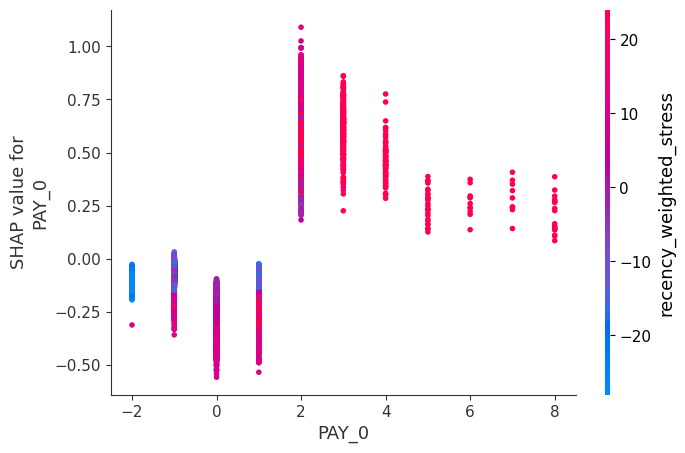

In [15]:
shap.dependence_plot(
    "PAY_0",
    shap_values,
    X
)

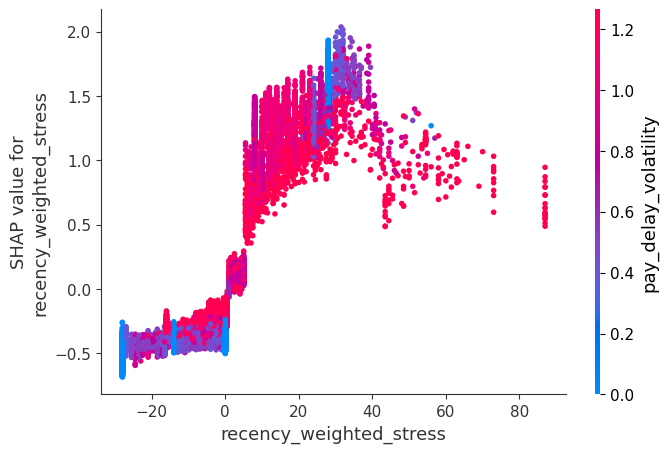

In [16]:
shap.dependence_plot(
    "recency_weighted_stress",
    shap_values,
    X
)

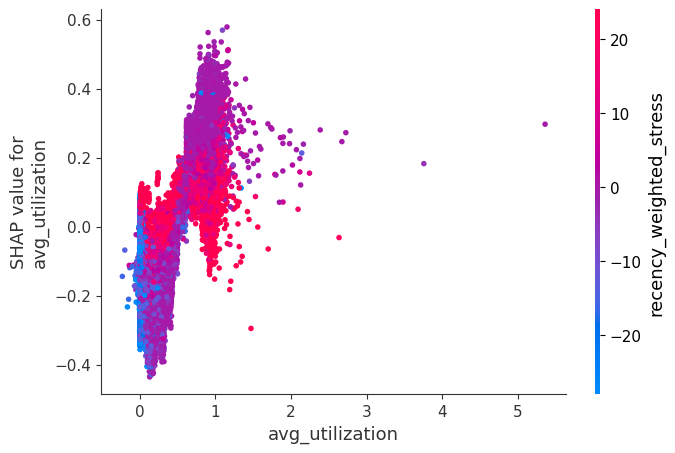

In [17]:
shap.dependence_plot(
    "avg_utilization",
    shap_values,
    X
)

## Business Insights

SHAP analysis reveals that the model relies primarily on behavioral indicators rather than demographic information.

The strongest drivers include:

- Recent repayment delays
- Recency-weighted financial stress
- Payment volatility
- Credit utilization
- Bill-to-payment ratio

These findings support the project's hypothesis that behavioral deterioration precedes default and that early intervention can be targeted before customers become severely delinquent.

The explanations generated by SHAP increase transparency, facilitate regulatory compliance, and improve trust in machine learning-based credit risk models.

SHAP summary figure saved.


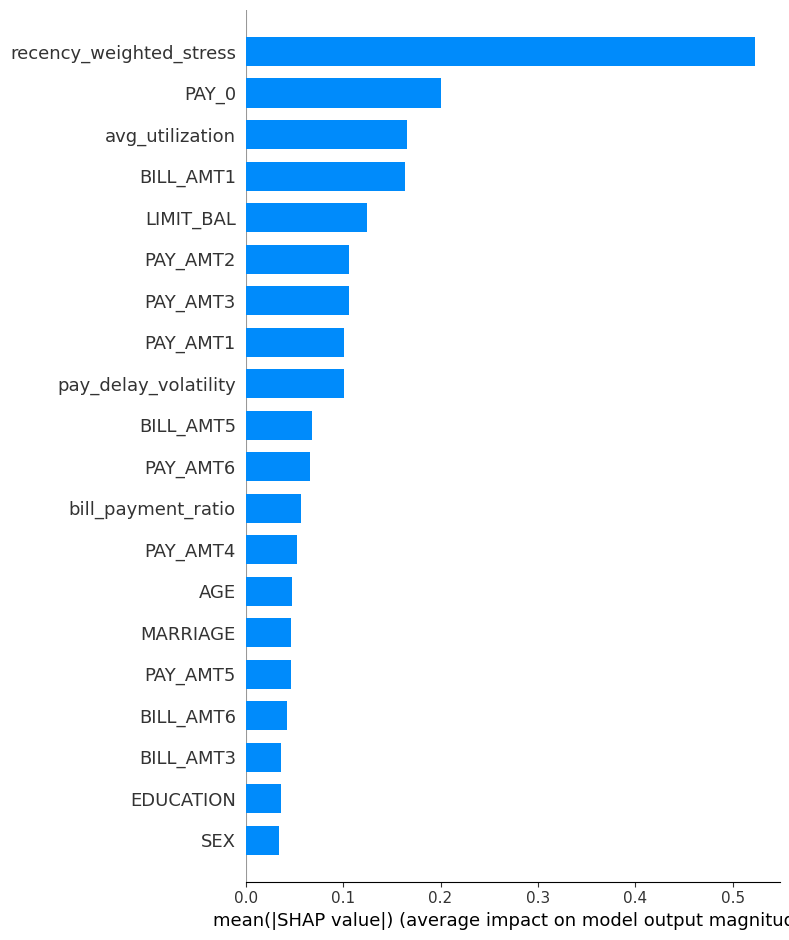

In [18]:
import os

os.makedirs(
    "/content/drive/MyDrive/Credit_Risk_Project/explainability",
    exist_ok=True
)

plt.figure(figsize=(8,6))

shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Credit_Risk_Project/explainability/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

print("SHAP summary figure saved.")

# Conclusion

SHAP complements traditional feature importance by providing both global and local explanations for model predictions.

Unlike standard importance measures, SHAP quantifies how each feature contributes to the predicted probability for every individual customer.

The explainability framework demonstrates that behavioral indicators such as repayment trends, financial stress, and utilization consistently drive model predictions, supporting the project's objective of detecting financial stress before default occurs.

This notebook enhances the transparency, interpretability, and practical applicability of the credit risk scoring system.